Train file: /content/IMT2024038_train_var2(in).csv | Test file: /content/IMT2024038_test_var2(in).csv
Train: (1000, 4) | Test: (1000, 3)

Ridge: best {'polynomialfeatures__degree': 10, 'ridge__alpha': 1}
   CV MSE = 0.2595 | CV R2 = 0.9946

Lasso: best {'lasso__alpha': 0.01, 'polynomialfeatures__degree': 15}
   CV MSE = 0.3603 | CV R2 = 0.9926

ElasticNet: best {'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.2, 'polynomialfeatures__degree': 16}
   CV MSE = 0.2907 | CV R2 = 0.9940

=== Ridge: results for every degree (1-20) ===
 Degree  Alpha  L1_ratio  CV_MSE  CV_R2  Train_MSE  Train_R2  Holdout_MSE  Holdout_R2
      1  10.00       NaN 35.2141 0.2672    34.6312    0.2922      34.8590      0.2481
      2   1.00       NaN 23.2709 0.5187    22.2965    0.5443      22.8746      0.5066
      3   1.00       NaN 11.4087 0.7613    10.3504    0.7884      11.9408      0.7425
      4   0.10       NaN  3.4642 0.9280     3.0104    0.9385       4.4231      0.9046
      5   0.10       NaN  1.472

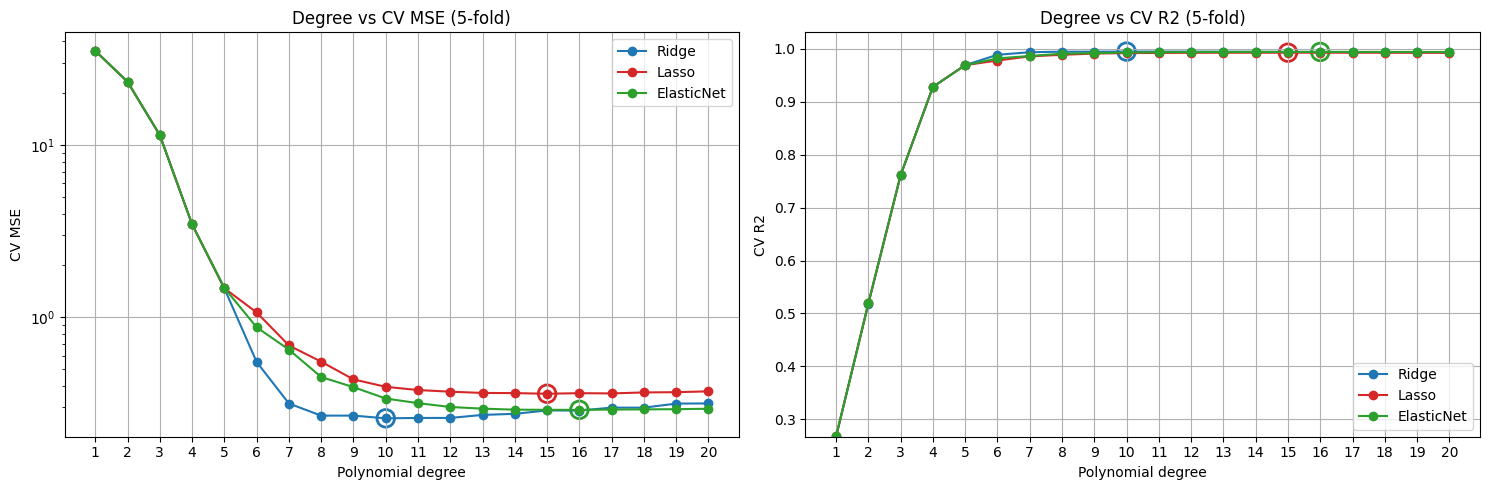

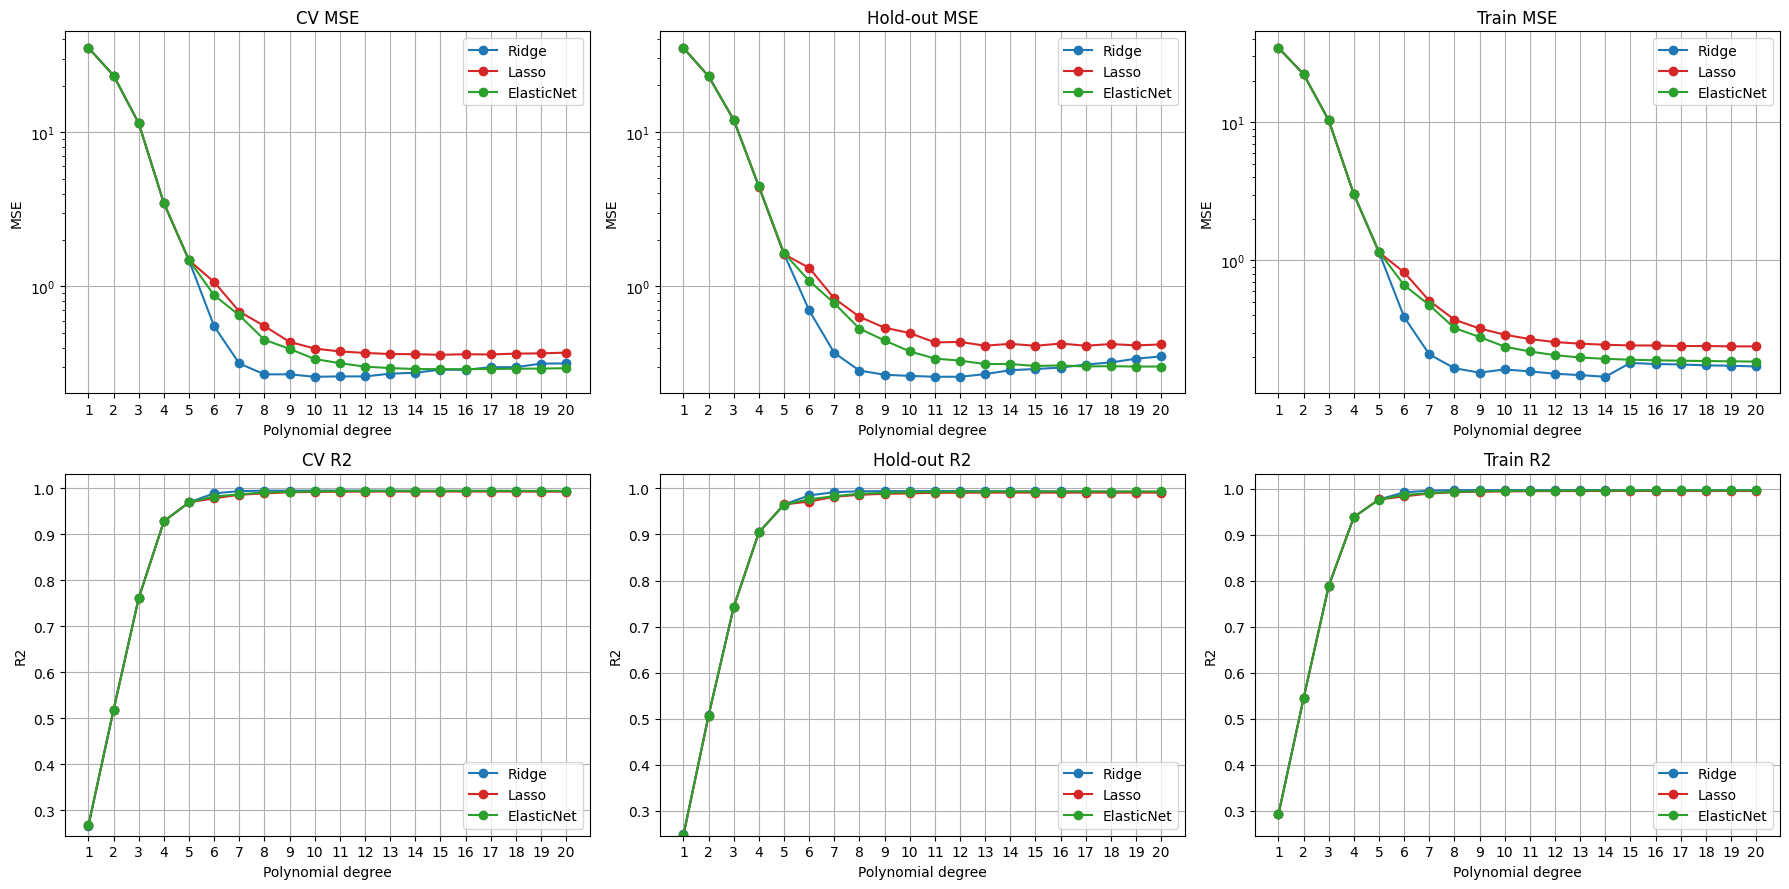

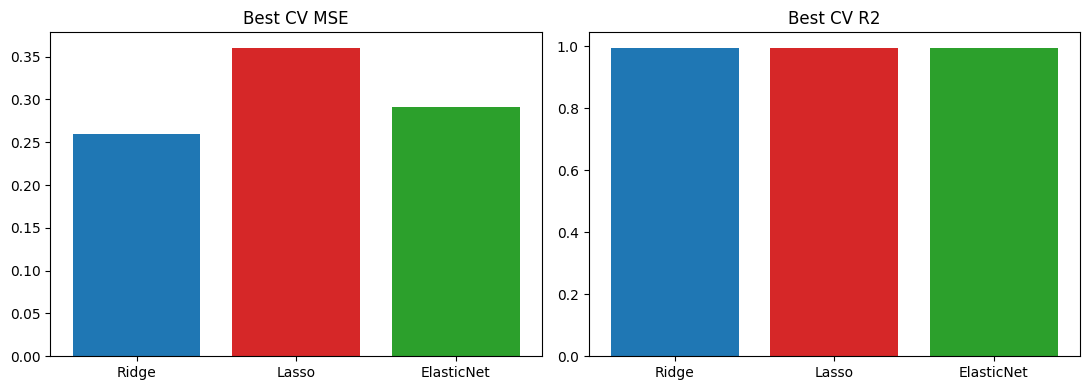

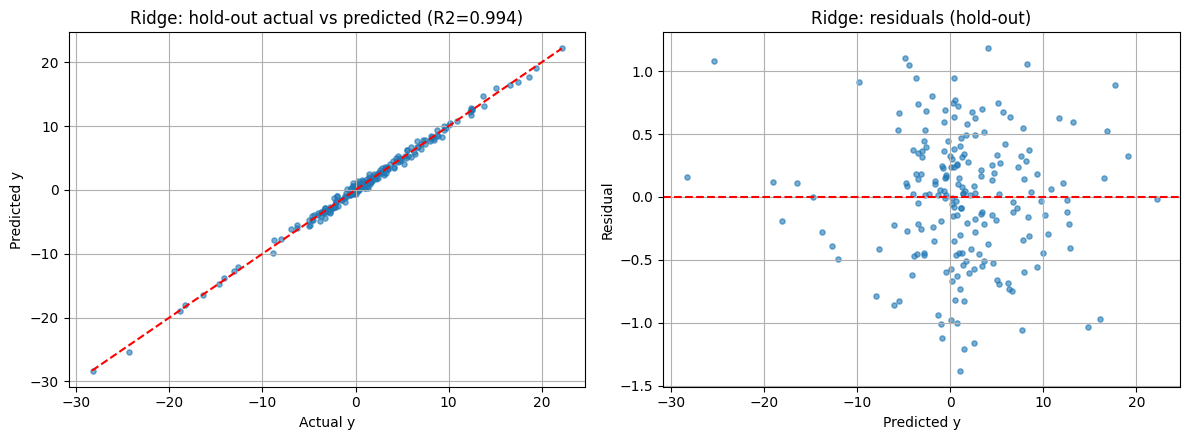

Lasso kept 270 of 815 polynomial terms
ElasticNet kept 523 of 968 polynomial terms

Saved: IMT2024038_pred_var2.csv (1000,)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import glob, warnings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
warnings.filterwarnings("ignore")

ROLL, PRB = "IMT2024038", 2
OUT_FILE = f"{ROLL}_pred_var{PRB}.csv"
N_FOLDS = 5

# ---------- 1. Load data ----------
def find(kw):
    base = "/content" if glob.glob("/content/*.csv") else "."
    c = [f for f in glob.glob(f"{base}/*.csv")
         if kw in f.lower() and f"var{PRB}" in f.lower() and "pred" not in f.lower()]
    assert len(c) == 1, f"Expected exactly one '{kw}' var{PRB} CSV, found: {c}"
    return c[0]
train_path, test_path = find("train"), find("test")
print("Train file:", train_path, "| Test file:", test_path)
train, test = pd.read_csv(train_path), pd.read_csv(test_path)
print("Train:", train.shape, "| Test:", test.shape)
X, y = train.drop(columns="y"), train["y"]

# ---------- 2. Hold-out split + CV ----------
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=42)
cv = KFold(N_FOLDS, shuffle=True, random_state=42)

# ---------- 3. Grid search: Ridge, Lasso, ElasticNet over degree 1-20 ----------
degrees = list(range(1, 21))
models = {
    "Ridge":      (Ridge(),                             {"alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]}),
    "Lasso":      (Lasso(max_iter=5000, tol=1e-2),      {"alpha": [1e-4, 1e-3, 1e-2, 1e-1]}),
    "ElasticNet": (ElasticNet(max_iter=5000, tol=1e-2), {"alpha": [1e-3, 1e-2, 1e-1],
                                                         "l1_ratio": [0.2, 0.5, 0.8]}),
}
scoring = {"mse": "neg_mean_squared_error", "r2": "r2"}

results, searches = {}, {}
for name, (est, params) in models.items():
    step = name.lower()
    pipe = make_pipeline(PolynomialFeatures(include_bias=False), StandardScaler(), est)
    grid = {"polynomialfeatures__degree": degrees}
    for p, vals in params.items():
        grid[f"{step}__{p}"] = vals
    gs = GridSearchCV(pipe, grid, cv=cv, scoring=scoring, refit="mse", n_jobs=-1)
    gs.fit(Xtr, ytr)
    searches[name] = gs
    r = pd.DataFrame(gs.cv_results_)
    r["deg"] = r["param_polynomialfeatures__degree"].astype(int)
    r["alpha"] = r[f"param_{step}__alpha"].astype(float)
    r["l1_ratio"] = r[f"param_{step}__l1_ratio"].astype(float) if name == "ElasticNet" else np.nan
    r["mse"] = -r["mean_test_mse"]
    r["r2"] = r["mean_test_r2"]
    results[name] = r
    i = gs.best_index_
    print(f"\n{name}: best {gs.best_params_}")
    print(f"   CV MSE = {r['mse'][i]:.4f} | CV R2 = {r['r2'][i]:.4f}")

# ---------- 4. Per-degree results for each model ----------
rows = []
for name, r in results.items():
    step = name.lower()
    for d in degrees:
        sub = r[r["deg"] == d]
        row = sub.loc[sub["mse"].idxmin()]
        m = clone(searches[name].estimator)
        m.set_params(polynomialfeatures__degree=d, **{f"{step}__alpha": row["alpha"]})
        if name == "ElasticNet":
            m.set_params(elasticnet__l1_ratio=row["l1_ratio"])
        m.fit(Xtr, ytr)
        ptr, pva = m.predict(Xtr), m.predict(Xva)
        rows.append([name, d, row["alpha"], row["l1_ratio"], row["mse"], row["r2"],
                     mean_squared_error(ytr, ptr), r2_score(ytr, ptr),
                     mean_squared_error(yva, pva), r2_score(yva, pva)])
per_deg = pd.DataFrame(rows, columns=["Model", "Degree", "Alpha", "L1_ratio", "CV_MSE", "CV_R2",
                                      "Train_MSE", "Train_R2", "Holdout_MSE", "Holdout_R2"])
pd.set_option("display.width", 250)
for name in models:
    print(f"\n=== {name}: results for every degree (1-20) ===")
    print(per_deg[per_deg.Model == name].drop(columns="Model").round(4).to_string(index=False))
per_deg.to_csv("var2_per_degree_results.csv", index=False)

# ---------- 5. Overall summary + winner ----------
rows = []
for name, gs in searches.items():
    step = name.lower(); i = gs.best_index_; bp = gs.best_params_
    rows.append([name, bp["polynomialfeatures__degree"], bp[f"{step}__alpha"],
                 bp.get(f"{step}__l1_ratio", np.nan),
                 results[name]["mse"][i], results[name]["r2"][i],
                 mean_squared_error(ytr, gs.predict(Xtr)), r2_score(ytr, gs.predict(Xtr)),
                 mean_squared_error(yva, gs.predict(Xva)), r2_score(yva, gs.predict(Xva))])
summary = pd.DataFrame(rows, columns=["Model", "Degree", "Alpha", "L1_ratio", "CV_MSE", "CV_R2",
                                      "Train_MSE", "Train_R2", "Holdout_MSE", "Holdout_R2"])
print("\n=== Best model of each type ===")
print(summary.round(4).to_string(index=False))
summary.to_csv("var2_model_comparison.csv", index=False)

best_name = summary.loc[summary["CV_MSE"].idxmin(), "Model"]
best_gs = searches[best_name]
print(f"\nWinner (lowest CV MSE): {best_name} {best_gs.best_params_}")

# ---------- 6. Plots: all three models together ----------
colors = {"Ridge": "tab:blue", "Lasso": "tab:red", "ElasticNet": "tab:green"}

# CV MSE and CV R2 side by side, all models on the same axes
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for name in models:
    d = per_deg[per_deg.Model == name]
    ax[0].plot(d.Degree, d.CV_MSE, marker="o", label=name, color=colors[name])
    ax[1].plot(d.Degree, d.CV_R2, marker="o", label=name, color=colors[name])
    bd = searches[name].best_params_["polynomialfeatures__degree"]
    ax[0].scatter([bd], [d.loc[d.Degree == bd, "CV_MSE"].values[0]], s=160, facecolors="none",
                  edgecolors=colors[name], linewidths=2)
    ax[1].scatter([bd], [d.loc[d.Degree == bd, "CV_R2"].values[0]], s=160, facecolors="none",
                  edgecolors=colors[name], linewidths=2)
ax[0].set(xlabel="Polynomial degree", ylabel="CV MSE", title=f"Degree vs CV MSE ({N_FOLDS}-fold)", xticks=degrees)
ax[0].set_yscale("log")
ax[1].set(xlabel="Polynomial degree", ylabel="CV R2", title=f"Degree vs CV R2 ({N_FOLDS}-fold)", xticks=degrees)
ax[1].set_ylim(bottom=max(-0.1, per_deg["CV_R2"].min()))
for a in ax: a.legend(); a.grid(True)
plt.tight_layout(); plt.savefig("var2_cv_mse_r2_comparison.png", dpi=150); plt.show()

# Train / hold-out / CV MSE and R2, all models
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
for j, (col, t) in enumerate([("CV", "CV"), ("Holdout", "Hold-out"), ("Train", "Train")]):
    for name in models:
        d = per_deg[per_deg.Model == name]
        ax[0, j].plot(d.Degree, d[f"{col}_MSE"], marker="o", label=name, color=colors[name])
        ax[1, j].plot(d.Degree, d[f"{col}_R2"], marker="o", label=name, color=colors[name])
    ax[0, j].set(xlabel="Polynomial degree", ylabel="MSE", title=f"{t} MSE", xticks=degrees)
    ax[0, j].set_yscale("log")
    ax[1, j].set(xlabel="Polynomial degree", ylabel="R2", title=f"{t} R2", xticks=degrees)
    ax[1, j].set_ylim(bottom=max(-0.1, per_deg[["CV_R2", "Holdout_R2", "Train_R2"]].min().min()))
    ax[0, j].legend(); ax[0, j].grid(True); ax[1, j].legend(); ax[1, j].grid(True)
plt.tight_layout(); plt.savefig("var2_all_metrics_vs_degree.png", dpi=150); plt.show()

# Bar chart: best CV MSE and R2 per model
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(summary.Model, summary.CV_MSE, color=[colors[m] for m in summary.Model]); ax[0].set(title="Best CV MSE")
ax[1].bar(summary.Model, summary.CV_R2, color=[colors[m] for m in summary.Model]); ax[1].set(title="Best CV R2")
plt.tight_layout(); plt.savefig("var2_best_bars.png", dpi=150); plt.show()

# Actual vs predicted + residuals for winner
pv = best_gs.predict(Xva)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(yva, pv, s=14, alpha=0.6)
lims = [min(yva.min(), pv.min()), max(yva.max(), pv.max())]
ax[0].plot(lims, lims, "r--")
ax[0].set(xlabel="Actual y", ylabel="Predicted y",
          title=f"{best_name}: hold-out actual vs predicted (R2={r2_score(yva, pv):.3f})")
ax[1].scatter(pv, yva - pv, s=14, alpha=0.6); ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="Predicted y", ylabel="Residual", title=f"{best_name}: residuals (hold-out)")
for a in ax: a.grid(True)
plt.tight_layout(); plt.savefig("var2_actual_vs_pred.png", dpi=150); plt.show()

# Sparsity
for name in ["Lasso", "ElasticNet"]:
    coef = searches[name].best_estimator_[-1].coef_
    print(f"{name} kept {int(np.sum(coef != 0))} of {len(coef)} polynomial terms")

# ---------- 7. Solve the question: refit winner on ALL train data, predict test ----------
final_model = best_gs.best_estimator_.fit(X, y)
pred = final_model.predict(test[X.columns])
pd.DataFrame({"y": pred}).to_csv(OUT_FILE, index=False)
print("\nSaved:", OUT_FILE, pred.shape)

from google.colab import files
for f in [OUT_FILE, "var2_model_comparison.csv", "var2_per_degree_results.csv",
          "var2_cv_mse_r2_comparison.png", "var2_all_metrics_vs_degree.png",
          "var2_best_bars.png", "var2_actual_vs_pred.png"]:
    files.download(f)